In [1]:
!date

Tue Jan 27 01:32:26 PM -03 2026


In [2]:
#%load_ext autoreload
%reload_ext autoreload
%autoreload 3

In [3]:
import sys
sys.path.append('../src')

try :
  from importlib import reload
  #reload(subsea.easy_search)
  #reload(subsea)
  reload(sub_es.dashboard)
  reload(sub_es)
except NameError :
  #import subsea
  import subsea.easy_search as sub_es


In [11]:
from importlib import reload
import subsea.service_class as service_class
reload(service_class)

<module 'subsea.service_class' from '/projetos/ghva/IA-Submarina-OnBoarding/notebook/../src/subsea/service_class.py'>

In [4]:
df = sub_es.load( )

In [10]:
df.sample()

id,os,group,group_norm,group_physical,group_count,desc,desc_norm,date,class,class_norm,class_physical,class_count,un,un_norm,un_physical,un_count,field_number,field_location,field_location_norm,field_location_physical,field_location_count,depth,suit,suit_norm,suit_physical,suit_count,shipment,company,company_norm,company_physical,company_count,resource,resource_norm,resource_physical,resource_count,vessel,vessel_norm,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_norm,bucket_physical,bucket_count,base,folder,path,source
i32,str,cat,cat,u32,u32,str,str,date,cat,cat,u32,u32,cat,cat,u32,u32,i16,cat,cat,u32,u32,i32,cat,cat,u32,u32,str,cat,cat,u32,u32,cat,cat,u32,u32,cat,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,cat,u32,u32,str,str,str,str
100832,"""6000727929""","""MER""","""mer""",101,12283,"""insp final casco- acfm - proba…","""mpi na solda da borboleta fair…",2024-07-15,"""Insp final CASCO- acfm - proba…","""insp final casco- acfm - proba…",2139,6,"""UN-BC - SEDE Bacia""","""un-bc - sede bacia""",98,29458,684,"""P-51""","""p-51""",192,1018,1205,"""Ciclo de renovacao""","""ciclo de renovacao""",1236,714,"""P-51 / 2023""","""SISTAC""","""sistac""",353,3475,"""SDSV""","""sdsv""",11,7642,"""Sistac Vitoria""","""sistac vitoria""",490,674,null,null,6,1.3303473e7,0,0.0,2025-04-08,2025-04-08,2025-04-09,2025-04-09,null,"""manutencao-inspecao-submarina""","""manutencao-inspecao-submarina""",22,51071,"""recursos-embarcacoes""","""OS006000727929-CLASSE""","""manutencao-inspecao-submarina/…","""Pacotes"""


In [11]:
df.select('class_norm').n_unique( )

469

In [10]:
sub_es.build_dashboard( df )

In [17]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from polars import DataFrame

from Levenshtein import distance as lev_distance

suits = df.select("class_norm").filter( pl.col( 'class_norm').is_not_null() ).unique( ).to_series( ).to_list( )
suits = [s for s in suits if s is not None]
dist_matrix = np.array([[lev_distance(a, b) for b in suits] for a in suits])

# Clustering: defina n_clusters conforme desejado
n_clusters = 80  # exemplo, ajuste conforme necessário
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
labels = clustering.fit_predict(dist_matrix)

# Crie um dicionário suit_norm -> cluster
suit_to_cluster = dict(zip(suits, labels))

In [22]:
import plotly.graph_objects as go
import polars as pl

def build_sankey(df: pl.DataFrame):
    # -----------------------------------------------------
    # Ensure required columns exist
    # -----------------------------------------------------
    required_cols = ["class_norm", "company_norm", "bucket", "files_size"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' is missing in dataframe.")
    # Remove nulls
    dfc = df.filter(
        pl.col("class_norm").is_not_null() &
        pl.col("company_norm").is_not_null() &
        pl.col("bucket").is_not_null() &
        pl.col("files_size").is_not_null()
    )
    df_with_cluster = dfc.with_columns(
        pl.col("class_norm").map_elements(
            lambda x: suit_to_cluster.get(x, -1),
            return_dtype=pl.Int32
        ).alias("class_cluster")
    )
    valid_clusters = (
        df_with_cluster
        .group_by("class_cluster")
        .agg(pl.len().alias("count"))
        .filter(pl.col("count") > 160)
        .select("class_cluster")
        .to_series()
    )
    valid_clusters_df = pl.DataFrame({"class_cluster": valid_clusters.to_list()})
    dfc = df_with_cluster.join(valid_clusters_df, on="class_cluster", how="inner")
    # -----------------------------------------------------
    # Build unique lists of nodes
    # -----------------------------------------------------
    class_list   = dfc["class_norm"].unique().to_list()
    company_list = dfc["company_norm"].unique().to_list()
    bucket_list  = dfc["bucket"].unique().to_list()

    # Concatenate into a single node list
    nodes = class_list + company_list + bucket_list
    # map each node to an index
    node_index = {name: i for i, name in enumerate(nodes)}

    n_class   = len(class_list)
    n_company = len(company_list)
    n_bucket  = len(bucket_list)

    # -----------------------------------------------------
    # CLASS → COMPANY flows (summing files_size)
    # -----------------------------------------------------
    df1 = (
        dfc.group_by(["class_norm", "company_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )

    src1 = [node_index[r["class_norm"]] for r in df1.iter_rows(named=True)]
    tgt1 = [node_index[r["company_norm"]] for r in df1.iter_rows(named=True)]
    val1 = [r["value"] for r in df1.iter_rows(named=True)]

    # -----------------------------------------------------
    # COMPANY → BUCKET flows
    # -----------------------------------------------------
    df2 = (
        dfc.group_by(["company_norm", "bucket"])
        .agg(pl.col("files_size").sum().alias("value"))
    )

    src2 = [node_index[r["company_norm"]] for r in df2.iter_rows(named=True)]
    tgt2 = [node_index[r["bucket"]] for r in df2.iter_rows(named=True)]
    val2 = [r["value"] for r in df2.iter_rows(named=True)]

    # -----------------------------------------------------
    # Compute incoming/outgoing per node
    # -----------------------------------------------------
    incoming = {n: 0.0 for n in nodes}
    outgoing = {n: 0.0 for n in nodes}

    # class -> company
    for s, t, v in zip(src1, tgt1, val1):
        outgoing[nodes[s]] += v
        incoming[nodes[t]] += v

    # company -> bucket
    for s, t, v in zip(src2, tgt2, val2):
        outgoing[nodes[s]] += v
        incoming[nodes[t]] += v

    # -----------------------------------------------------
    # Prepare hover customdata
    # -----------------------------------------------------
    def format_tb(x):
        return f"{x/1024:.2f} TB"

    customdata = [
        [format_tb(incoming[n]), format_tb(outgoing[n])]
        for n in nodes
    ]

    # -----------------------------------------------------
    # Sankey node settings
    # -----------------------------------------------------
    node = dict(
        label=nodes,        # KEEP LABELS CLEAN
        pad=20,
        thickness=20,
        color="rgba(50,50,50,0.8)",
        customdata=customdata,
        hovertemplate=(
            "<b>%{label}</b><br>" +
            "Incoming: %{customdata[0]}<br>" +
            "Outgoing: %{customdata[1]}<br>" +
            "<extra></extra>"
        )
    )

    link = dict(
        source = src1 + src2,
        target = tgt1 + tgt2,
        value  = val1 + val2,
        color  = (["rgba(100,149,237,0.4)"] * len(src1)) +
                 (["rgba(60,179,113,0.4)"] * len(src2)),
        hovertemplate = (
            "Flow: %{value} (files_size)<extra></extra>"
        )
    )

    fig = go.Figure(data=[go.Sankey(node=node, link=link)])
    fig.update_layout(
        title="Class → Company → Bucket (files_size flow)",
        font_size=12,
        height=750
    )
    return fig

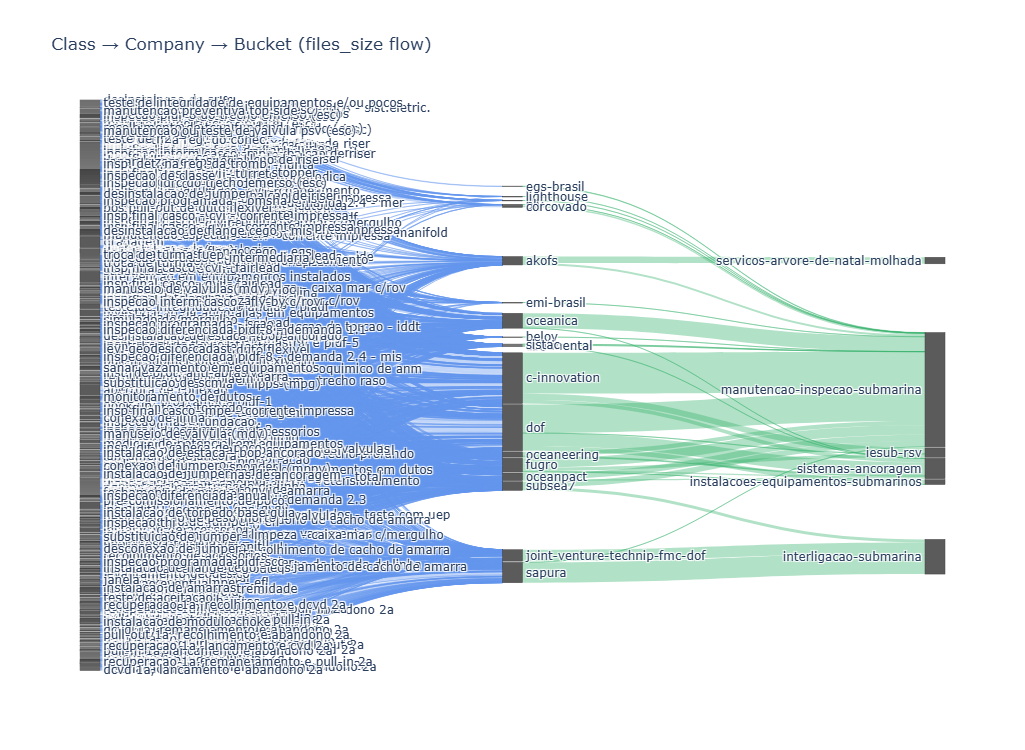

In [23]:
fig = build_sankey(df)
fig.show()

In [24]:
import plotly.graph_objects as go
import polars as pl
def build_sankey(df: pl.DataFrame):
    required_cols=["class_norm","company_norm","un_norm","bucket_norm","files_size"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' is missing in dataframe.")
    dfc=df.filter(
        pl.col("class_norm").is_not_null()&
        pl.col("company_norm").is_not_null()&
        pl.col("un_norm").is_not_null()&
        pl.col("bucket_norm").is_not_null()&
        pl.col("files_size").is_not_null()
    )
    df_with_cluster=dfc.with_columns(
        pl.col("class_norm").map_elements(
            lambda x:suit_to_cluster.get(x,-1),
            return_dtype=pl.Int32
        ).alias("class_cluster")
    )
    valid_clusters=(
        df_with_cluster
        .group_by("class_cluster")
        .agg(pl.len().alias("count"))
        .filter(pl.col("count")>160)
        .select("class_cluster")
        .to_series()
    )
    valid_clusters_df=pl.DataFrame({"class_cluster":valid_clusters.to_list()})
    dfc=df_with_cluster.join(valid_clusters_df,on="class_cluster",how="inner")
    class_list=dfc["class_norm"].unique().to_list()
    company_list=dfc["company_norm"].unique().to_list()
    un_list=dfc["un_norm"].unique().to_list()
    bucket_list=dfc["bucket_norm"].unique().to_list()
    nodes=class_list+company_list+un_list+bucket_list
    node_index={name:i for i,name in enumerate(nodes)}
    df1=(
        dfc.group_by(["class_norm","company_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )
    src1=[node_index[r["class_norm"]] for r in df1.iter_rows(named=True)]
    tgt1=[node_index[r["company_norm"]] for r in df1.iter_rows(named=True)]
    val1=[r["value"] for r in df1.iter_rows(named=True)]
    df2=(
        dfc.group_by(["company_norm","un_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )
    src2=[node_index[r["company_norm"]] for r in df2.iter_rows(named=True)]
    tgt2=[node_index[r["un_norm"]] for r in df2.iter_rows(named=True)]
    val2=[r["value"] for r in df2.iter_rows(named=True)]
    df3=(
        dfc.group_by(["un_norm","bucket_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )
    src3=[node_index[r["un_norm"]] for r in df3.iter_rows(named=True)]
    tgt3=[node_index[r["bucket_norm"]] for r in df3.iter_rows(named=True)]
    val3=[r["value"] for r in df3.iter_rows(named=True)]
    incoming={n:0.0 for n in nodes}
    outgoing={n:0.0 for n in nodes}
    for s,t,v in zip(src1,tgt1,val1):
        outgoing[nodes[s]]+=v
        incoming[nodes[t]]+=v
    for s,t,v in zip(src2,tgt2,val2):
        outgoing[nodes[s]]+=v
        incoming[nodes[t]]+=v
    for s,t,v in zip(src3,tgt3,val3):
        outgoing[nodes[s]]+=v
        incoming[nodes[t]]+=v
    def format_tb(x):return f"{x/1024:.2f} TB"
    customdata=[[format_tb(incoming[n]),format_tb(outgoing[n])] for n in nodes]
    node=dict(
        label=nodes,
        pad=20,
        thickness=20,
        color="rgba(50,50,50,0.8)",
        customdata=customdata,
        hovertemplate="<b>%{label}</b><br>Incoming: %{customdata[0]}<br>Outgoing: %{customdata[1]}<extra></extra>"
    )
    link=dict(
        source=src1+src2+src3,
        target=tgt1+tgt2+tgt3,
        value=val1+val2+val3,
        color=(["rgba(100,149,237,0.4)"]*len(src1))+(["rgba(255,140,0,0.4)"]*len(src2))+(["rgba(60,179,113,0.4)"]*len(src3)),
        hovertemplate="Flow: %{value} (files_size)<extra></extra>"
    )
    fig=go.Figure(data=[go.Sankey(node=node,link=link)])
    fig.update_layout(title="class_norm → company_norm → un_norm → bucket_norm (files_size flow)",font_size=12,height=780)
    return fig

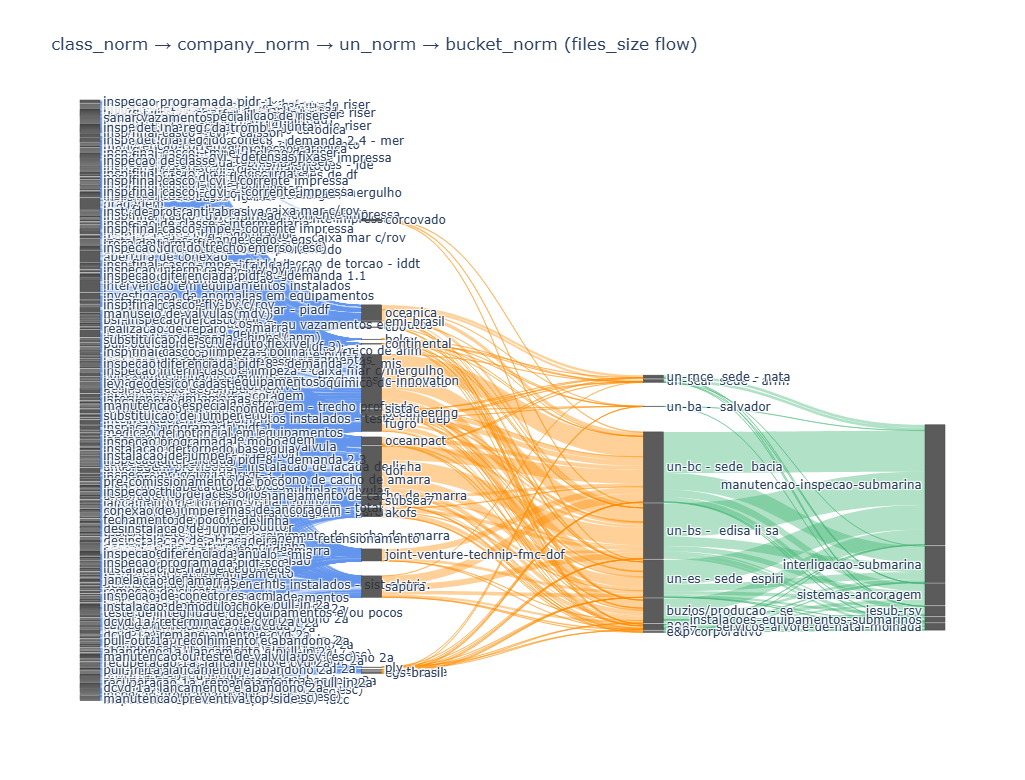

In [25]:
fig = build_sankey(df)
fig.show()

In [50]:
def build_sankey(df: pl.DataFrame):
    TOP_N_CLASS=15
    TOP_N_COMPANY=20
    TOP_N_UN=20
    TOP_N_BUCKET=20
    required=["class_norm","company_norm","un_norm","bucket_norm","files_size"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Column '{c}' missing.")
    dfc=df.filter(
        pl.col("class_norm").is_not_null()&
        pl.col("company_norm").is_not_null()&
        pl.col("un_norm").is_not_null()&
        pl.col("bucket_norm").is_not_null()&
        pl.col("files_size").is_not_null()
    )
    dfc=dfc.with_columns(
        pl.col("class_norm").map_elements(
            lambda x: suit_to_cluster.get(x,-1),
            return_dtype=pl.Int32
        ).alias("class_cluster")
    )
    valid=(
        dfc.group_by("class_cluster")
        .agg(pl.len().alias("count"))
        .filter(pl.col("count")>160)
        .select("class_cluster")
        .to_series()
        .to_list()
    )
    dfc=dfc.filter(pl.col("class_cluster").is_in(valid))
    def topn(col,n):
        top=dfc.group_by(col).agg(pl.col("files_size").sum().alias("size")).sort("size",descending=True).head(n)
        keep=set(top[col].to_list())
        return dfc.with_columns(
            pl.when(pl.col(col).is_in(keep))
            .then(pl.col(col))
            .otherwise(pl.lit(f"OTHER_{col.upper()}"))
            .alias(col)
        )
    dfc=topn("class_norm",TOP_N_CLASS)
    dfc=topn("company_norm",TOP_N_COMPANY)
    dfc=topn("un_norm",TOP_N_UN)
    dfc=topn("bucket_norm",TOP_N_BUCKET)
    class_list=dfc["class_norm"].unique().to_list()
    company_list=dfc["company_norm"].unique().to_list()
    un_list=dfc["un_norm"].unique().to_list()
    bucket_list=dfc["bucket_norm"].unique().to_list()
    nodes=class_list+company_list+un_list+bucket_list
    node_index={n:i for i,n in enumerate(nodes)}
    f1=(
        dfc.group_by(["class_norm","company_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )
    src1=[node_index[r["class_norm"]] for r in f1.iter_rows(named=True)]
    tgt1=[node_index[r["company_norm"]] for r in f1.iter_rows(named=True)]
    val1=[r["value"] for r in f1.iter_rows(named=True)]
    f2=(
        dfc.group_by(["company_norm","un_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )
    src2=[node_index[r["company_norm"]] for r in f2.iter_rows(named=True)]
    tgt2=[node_index[r["un_norm"]] for r in f2.iter_rows(named=True)]
    val2=[r["value"] for r in f2.iter_rows(named=True)]
    f3=(
        dfc.group_by(["un_norm","bucket_norm"])
        .agg(pl.col("files_size").sum().alias("value"))
    )
    src3=[node_index[r["un_norm"]] for r in f3.iter_rows(named=True)]
    tgt3=[node_index[r["bucket_norm"]] for r in f3.iter_rows(named=True)]
    val3=[r["value"] for r in f3.iter_rows(named=True)]
    incoming={n:0.0 for n in nodes}
    outgoing={n:0.0 for n in nodes}
    for s,t,v in zip(src1,tgt1,val1):
        outgoing[nodes[s]]+=v
        incoming[nodes[t]]+=v
    for s,t,v in zip(src2,tgt2,val2):
        outgoing[nodes[s]]+=v
        incoming[nodes[t]]+=v
    for s,t,v in zip(src3,tgt3,val3):
        outgoing[nodes[s]]+=v
        incoming[nodes[t]]+=v
    def fmt(x):return f"{x/1024:.2f} TB"
    custom=[[fmt(incoming[n]),fmt(outgoing[n])] for n in nodes]
    link_values=val1+val2+val3
    vmax=max(link_values)
    vmin=min(link_values)
    def color_scale(v):
        x=(v-vmin)/(vmax-vmin+1e-9)
        r=int(255*x)
        g=int(120*(1-x))
        b=int(40*(1-x))
        return f"rgba({r},{g},{b},0.55)"
    link_colors=[color_scale(v) for v in link_values]
    node=dict(
        label=[f"<span style='color:black'>{n}</span>" for n in nodes],
        pad=20,
        thickness=20,
        color="rgba(40,40,40,0.9)",
        customdata=custom,
        hovertemplate="<b>%{label}</b><br>Incoming: %{customdata[0]}<br>Outgoing: %{customdata[1]}<extra></extra>"
    )
    link=dict(
        source=src1+src2+src3,
        target=tgt1+tgt2+tgt3,
        value=link_values,
        color=link_colors,
        hovertemplate="Flow: %{value}<extra></extra>"
    )
    fig=go.Figure(data=[go.Sankey(node=node,link=link)])
    fig.update_layout(
        title="class_norm → company_norm → un_norm → bucket_norm (Top-N, OTHER, Volume-colored)",
        font_size=12,
        height=820
    )
    return fig

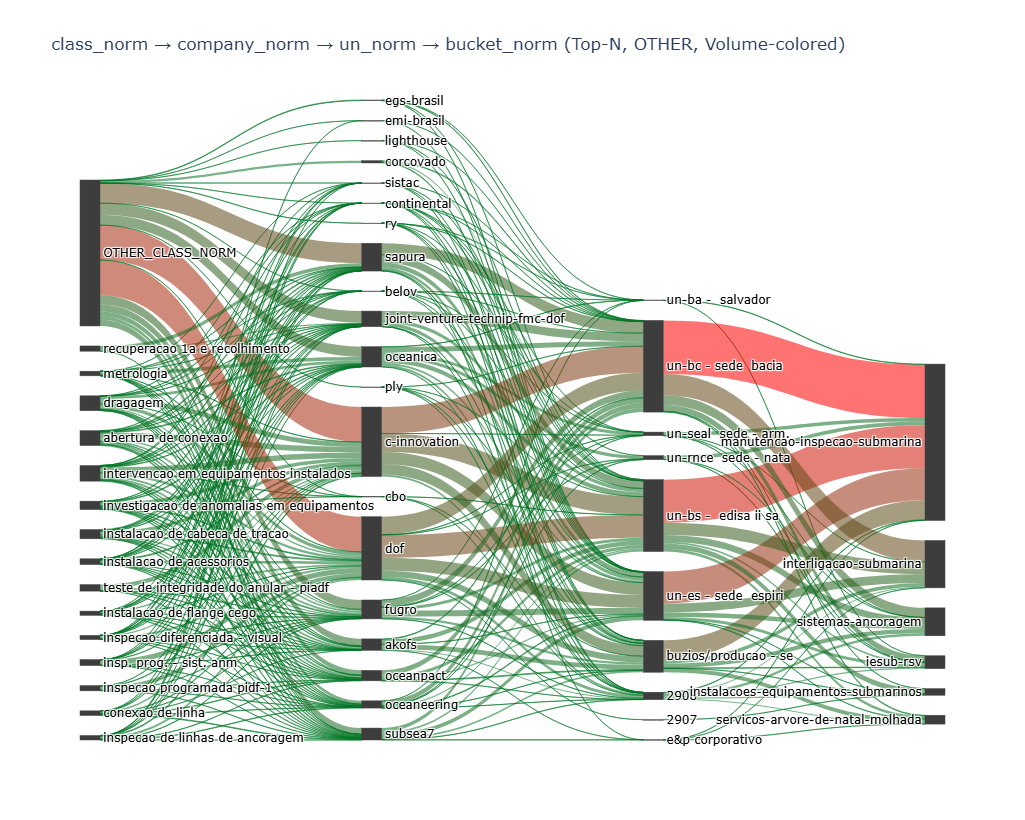

In [51]:
fig = build_sankey(df)
fig.show()